# TODO
- deep known about dataset
- Preprocessing
- compare some scaler options (stand normalization, min max scaler)
- Combine feature 

### Import required libraries
Import pandas, numpy, seaborn, and matplotlib for data manipulation and visualization.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Suppress warnings
Configure the warnings module to ignore non‑critical warnings.

In [2]:
import warnings

warnings.filterwarnings("ignore")

### Pull dataset and anomalies from database

In [164]:
from src.db.analyzer import FraudAnalyzer

analyzer = FraudAnalyzer()

df_train = analyzer.get_ml_feature()
df_anomalies = analyzer.get_anomalies()

Fetching Feature Table for ML
Scanning for anomalous transactions


In [14]:
# df = pd.DataFrame(df_train)
df = pd.read_csv("onlinefraud.csv")
df = df.drop(columns= "isFlaggedFraud")

craw = df
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0
...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1


## Exploratory Data Analysis (EDA)

### 1.Inspect Data

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
dtypes: float64(5), int64(2), str(3)
memory usage: 485.4 MB


In [16]:
df.shape

(6362620, 10)

In [17]:
df.sample(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
3778052,280,PAYMENT,10846.85,C1934816720,43055.00,32208.15,M285942726,0.00,0.00,0
3023716,233,CASH_OUT,163772.35,C195916023,0.00,0.00,C2029811955,1053702.32,1217474.66,0
3620778,274,PAYMENT,5649.61,C1206748977,0.00,0.00,M746577964,0.00,0.00,0
2808696,225,CASH_OUT,124673.32,C2045172218,20789.00,0.00,C1564416075,264194.17,388867.49,0
4150728,303,CASH_IN,331798.92,C1541026689,647497.86,979296.77,C2046705786,1032150.52,700351.60,0


### 2.Verify Missing Values
Count missing values per column to ensure data completeness.

In [18]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64


- No columns contain null values

### 3.Detect Duplicate Rows

In [19]:
df.duplicated().sum()

np.int64(0)

- No duplicate rows

### 4.Fix Data Types

In [31]:
df['type'] = df['type'].astype('category')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 10 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int64   
 1   type            category
 2   amount          float64 
 3   nameOrig        str     
 4   oldbalanceOrg   float64 
 5   newbalanceOrig  float64 
 6   nameDest        str     
 7   oldbalanceDest  float64 
 8   newbalanceDest  float64 
 9   isFraud         int64   
dtypes: category(1), float64(5), int64(2), str(2)
memory usage: 443.0 MB


### 5.Summary Statistics For Numeric Features

In [28]:
df.describe(include= [np.number]).T

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00


### 6.Summary Statistics For Categorical Features

In [32]:
# df.describe(include= ["category"]).T
df.describe(include= ['str', 'category']).T

,count,unique,top,freq
type,6362620,5,CASH_OUT,2237500
nameOrig,6362620,6353307,C2098525306,3
nameDest,6362620,2722362,C1286084959,113


### 7. Explore Category Features

In [33]:
for i in df.select_dtypes(include= "category").columns:
    print(df[i].value_counts())
    print("***" * 10)

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64
******************************


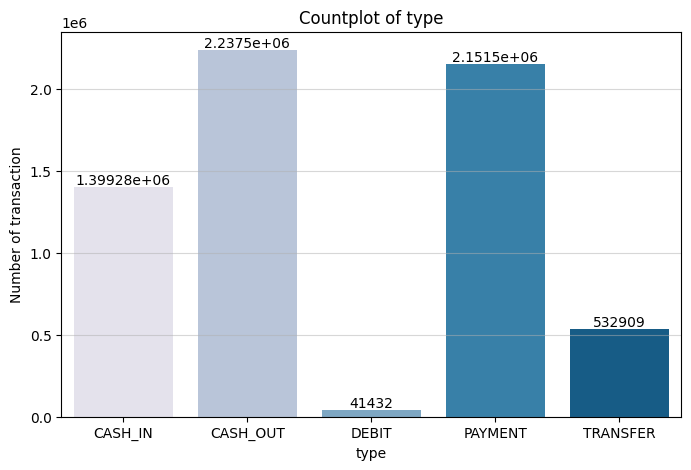

In [63]:
col = 'type'

plt.figure(figsize=(8, 5))

ax = sns.countplot(x=col, data=df, palette= 'PuBu')

for container in ax.containers:
    ax.bar_label(container)

plt.grid(axis='y', alpha= 0.5)
plt.title(f'Countplot of {col}')
plt.ylabel('Number of transaction')
plt.show()

### 8. Boxplots & Histograms

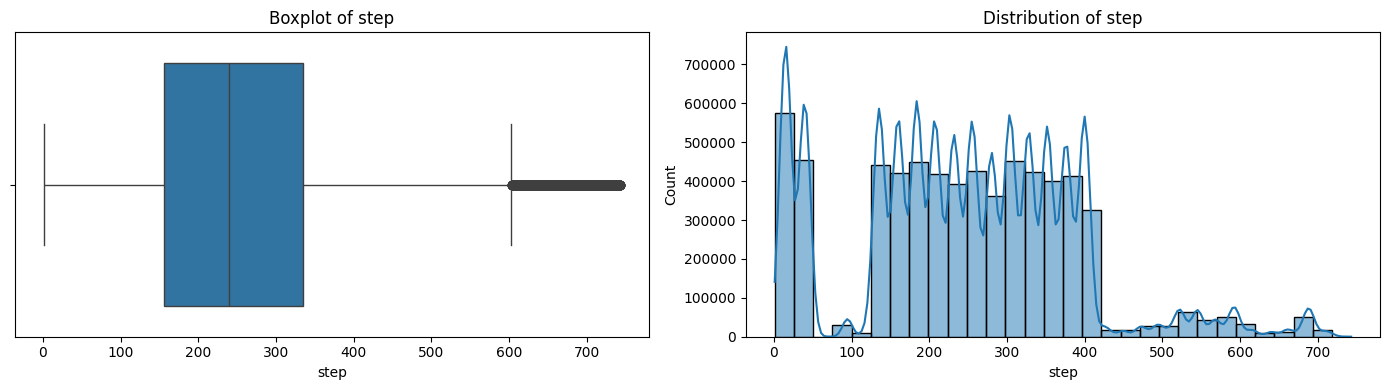

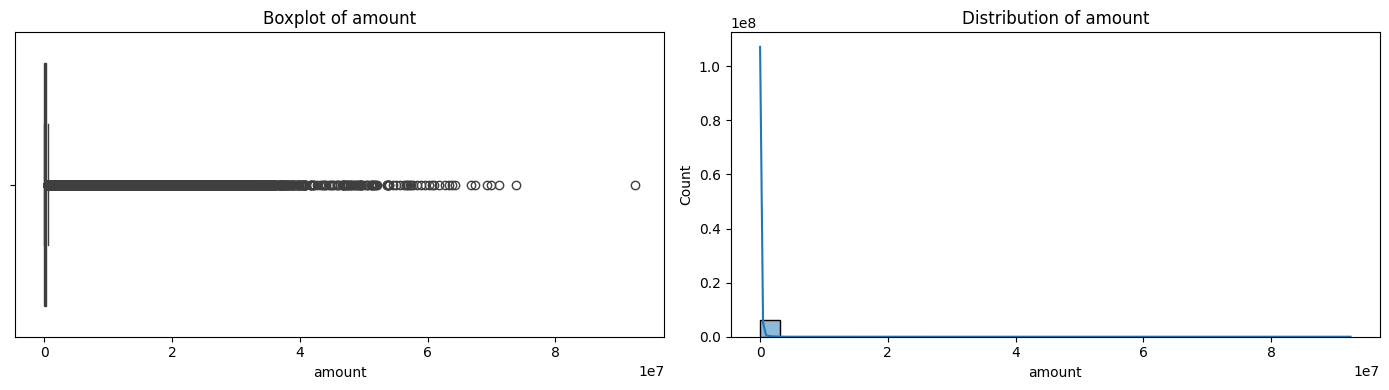

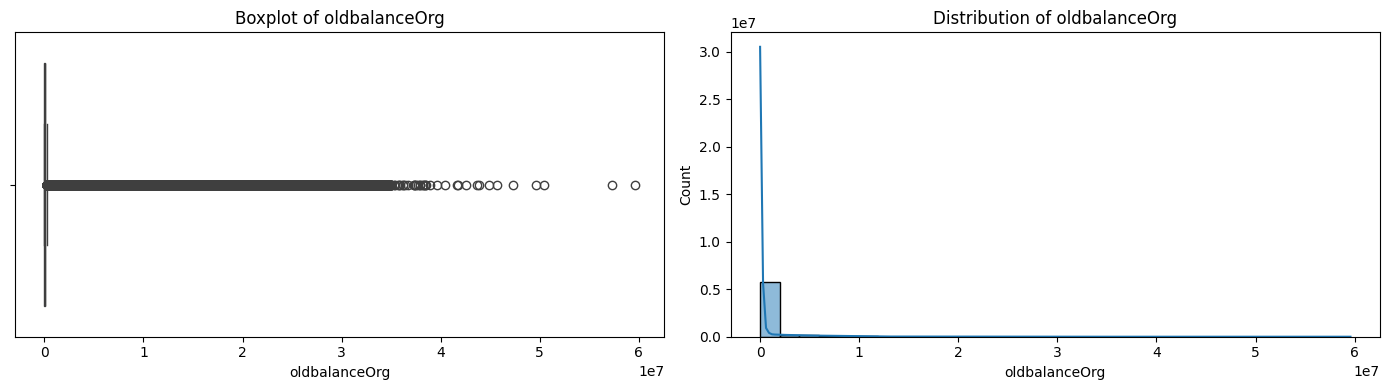

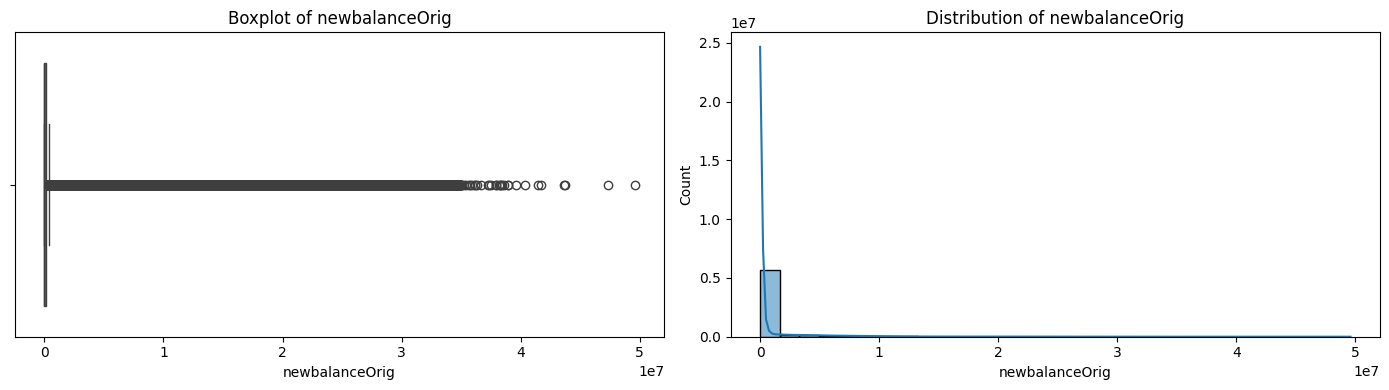

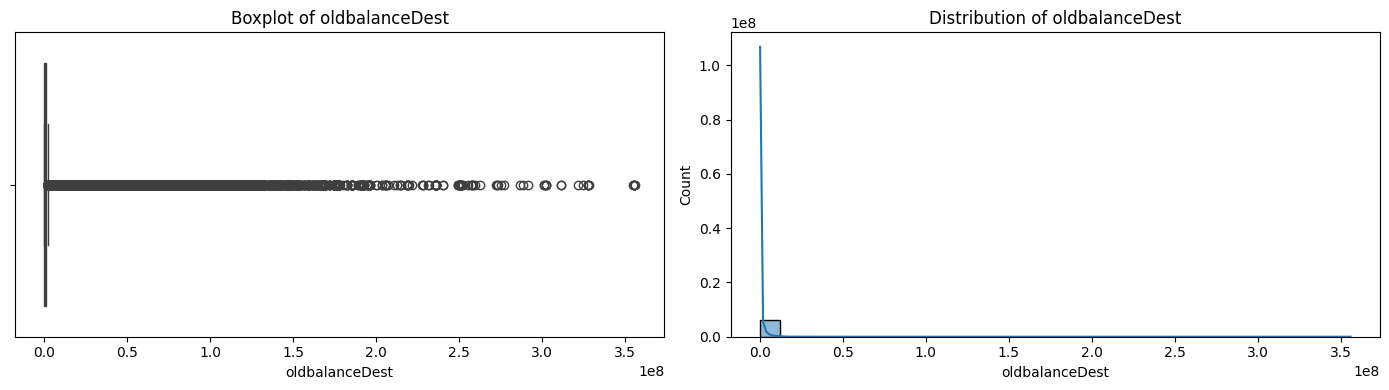

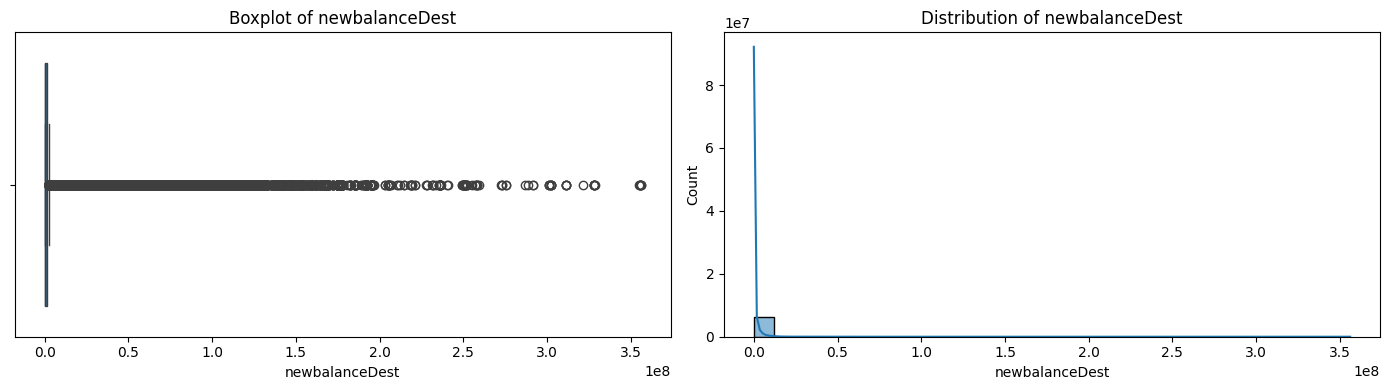

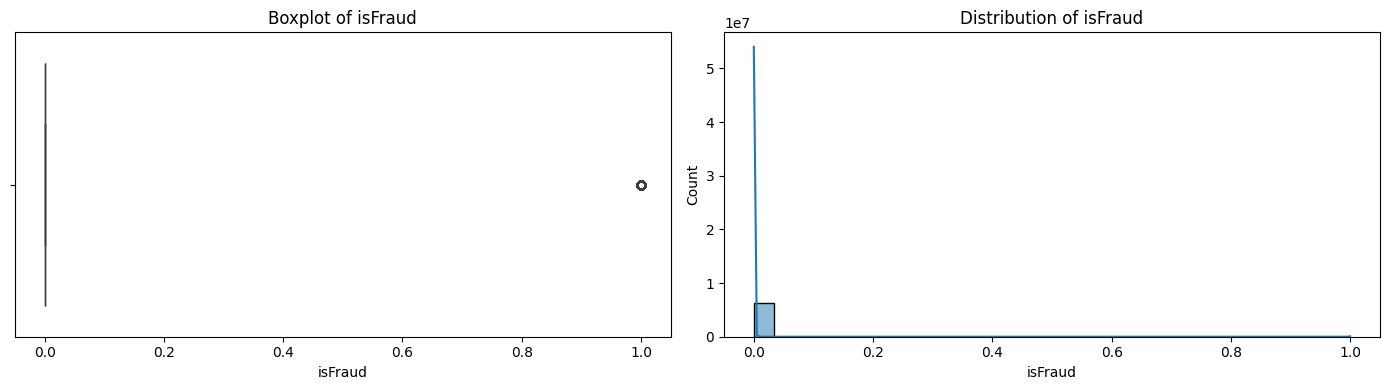

In [64]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[0])
    axes[0].set_title(f'Boxplot of {col}')

    # Histogram
    sns.histplot(df[col], kde=True, bins=30, ax=axes[1])
    axes[1].set_title(f'Distribution of {col}')

    plt.tight_layout()
    plt.show()

### 9.Heatmap Correlation

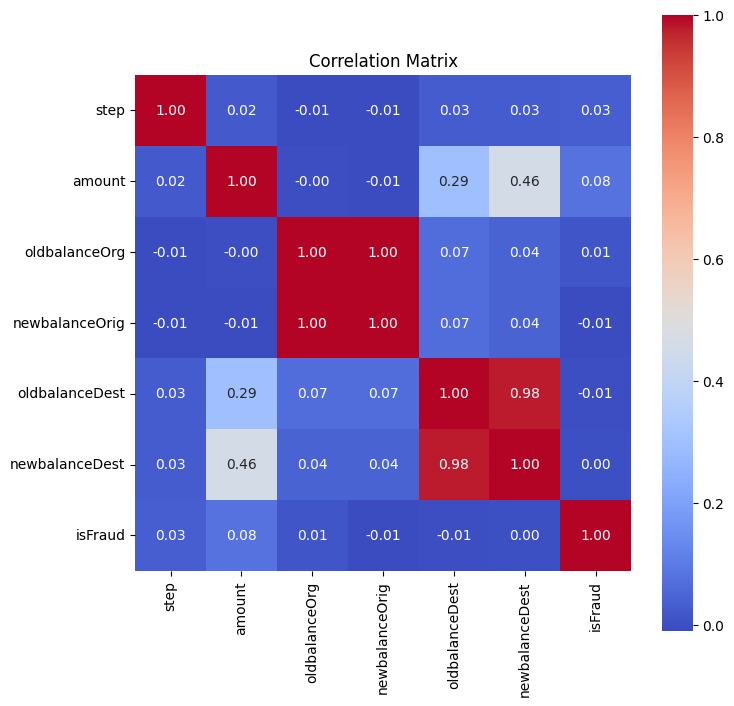

In [65]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

### 10.Target Class Distribution

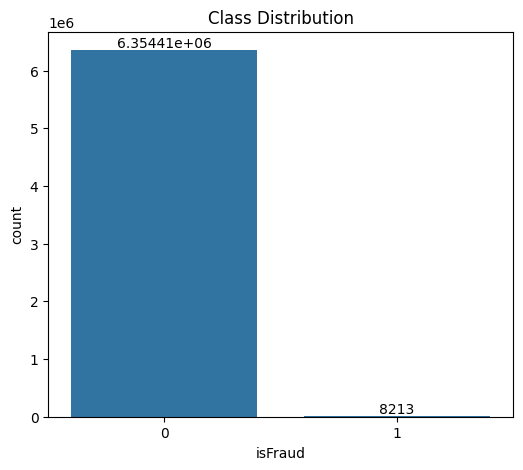

Class counts:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [69]:
target = 'isFraud'
plt.figure(figsize=(6, 5))
ax = sns.countplot(x=df[target])
for container in ax.containers:
    ax.bar_label(container)

plt.title('Class Distribution')
plt.show()

print('Class counts:')
print(df[target].value_counts())

### 11.Scatterplot

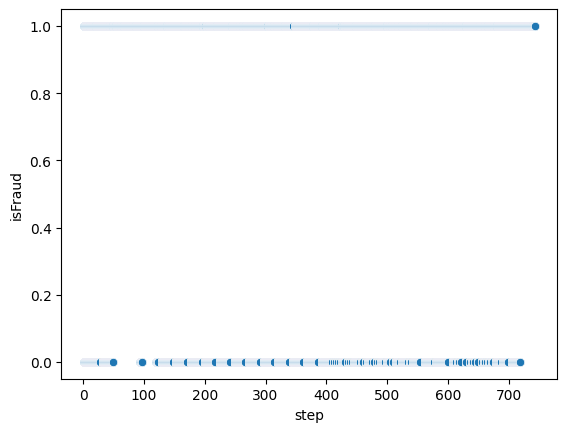

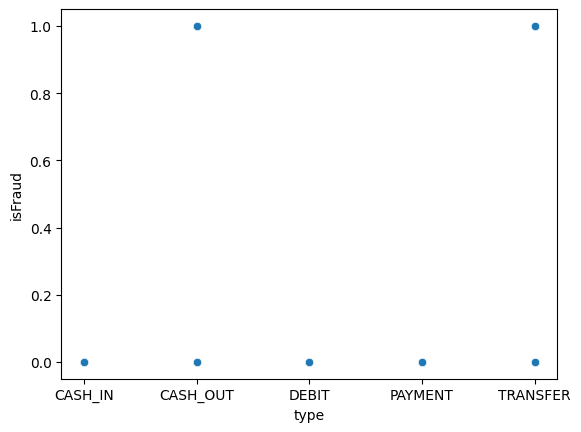

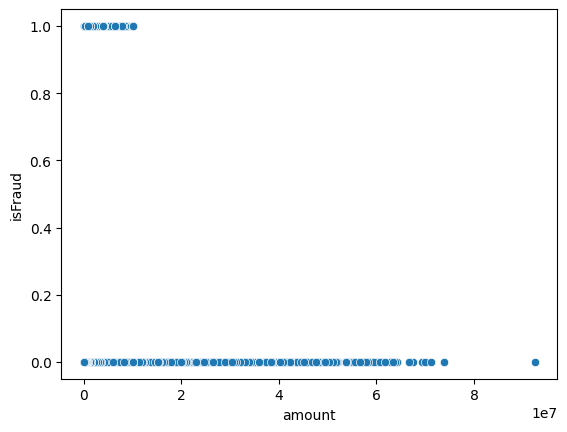

KeyboardInterrupt: 

In [ ]:
for i in ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest']:
    sns.scatterplot(data= df, x = i, y= 'isFraud')
    plt.show()

## Preprocessing

### Outliers Treatment

In [190]:
# df = craw

In [ ]:
# df['transaction_amount'] = np.log1p(df['transaction_amount'])

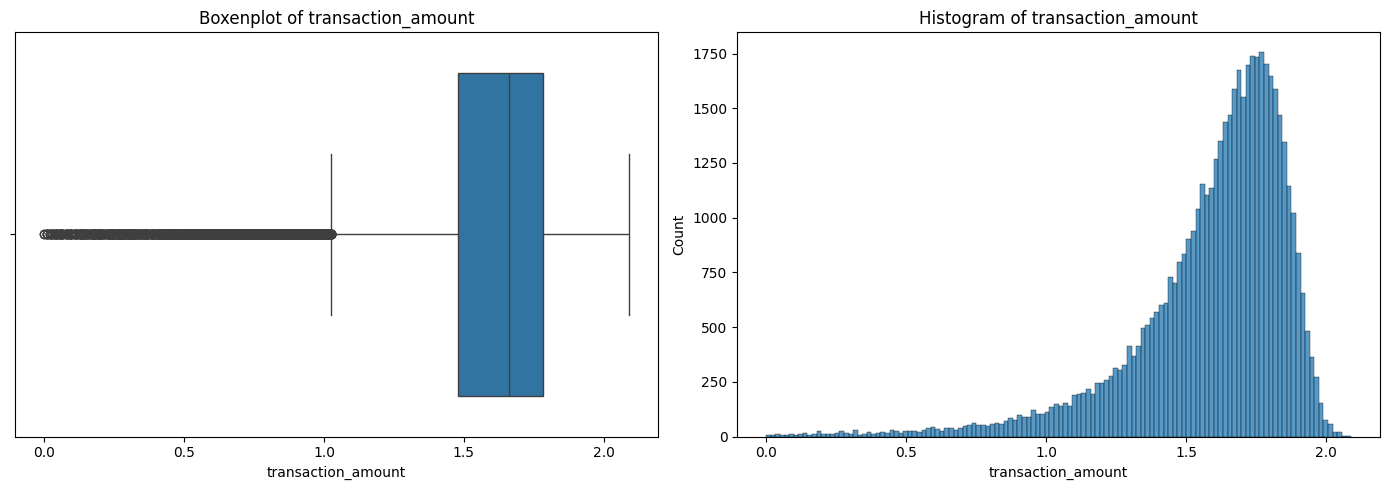

In [ ]:
# cols = ['transaction_amount']

# for col in cols:
    
#     fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#     # Boxenplot
#     sns.boxplot(x=df[col], ax=axes[0])
#     axes[0].set_title(f'Boxenplot of {col}')

#     # Histogram
#     sns.histplot(data=df, x=col, ax=axes[1])
#     axes[1].set_title(f'Histogram of {col}')

#     plt.tight_layout()
#     plt.show()

### Encoding

In [ ]:
#category = ['transaction_type', 'device_type', 'location', 'merchant_category',
#        'authentication_method']
# df = pd.get_dummies(data= df, columns= category, drop_first= True, dtype = int)

### Normalization

In [ ]:
# from sklearn.preprocessing import RobustScaler

# robust = RobustScaler()
# scale_cols = ['account_balance','avg_transaction_amount_7d','card_age','transaction_distance']
# df[scale_cols] = robust.fit_transform(df[scale_cols])